<div style="background:linear-gradient(135deg,#0c061a 0%,#1b0e37 30%,#3b1c5a 60%,#7b2d2d 100%);padding:36px 32px 28px 32px;border-radius:20px;border:1px solid rgba(255,120,120,0.2);position:relative;overflow:hidden;margin-bottom:6px;">
<div style="position:absolute;top:0;left:0;right:0;bottom:0;font-size:70px;line-height:1.1;word-break:break-all;color:rgba(255,122,122,0.035);pointer-events:none;overflow:hidden;">∑λ∇∞∂Σ∇λ∞∂Σ∇λ∞</div>
<div style="position:relative;z-index:1;">
<div style="font-size:10px;font-weight:600;letter-spacing:3px;text-transform:uppercase;color:rgba(255,255,255,0.5);margin-bottom:10px;font-family:monospace;">🔥 WiDS Global Datathon 2026 · Survival Modeling</div>
<h1 style="margin:0 0 6px 0;font-size:32px;font-weight:400;letter-spacing:-0.5px;line-height:1.2;color:#ffffff;">Tri-Survival <span style="color:#ff9a9a;font-style:italic;">Stack</span></h1>
<p style="margin:0 0 14px 0;font-size:15px;color:rgba(255,255,255,0.8);line-height:1.6;font-family:monospace;">Wildfire Evacuation Zone Hit Probability<br><span style="color:rgba(255,255,255,0.45);font-size:12px;">GBSA · CoxPH · Random Survival Forest · Zone-Split LGB · Distance-Stratified Blend</span></p>
</div>
</div>

# WiDS Global Datathon 2026 — Tri-Survival Stack

**Pipeline:**
- **GBSA** — Gradient Boosting Survival Analysis (tree-based, original)
- **CoxPH** — Cox Proportional Hazards (linear in log-hazard space) 🆕
- **RSF** — Random Survival Forest (bagged trees, different structure) 🆕
- **LGB IPCW (Zone-Split)** — separate near/far classifiers per horizon 🆕
- **Near-Zone Timing Model** — log-normal regression on time-to-hit for certain-hit fires 🆕
- **Distance-Stratified Blend** — near/far blend + timing model integration 🆕
- **72h** = `constant1` (proven best LB across all previous runs)


## Problem Framing
We predict P(wildfire hits evacuation zone by horizon h) for h ∈ {12, 24, 48, 72} hours.

**Metric:** `0.3 × C-index + 0.7 × (1 − WBrier)` where `WBrier = 0.3×B24 + 0.4×B48 + 0.3×B72`.

**Key dataset facts:**
- Only **221 training rows** — overfitting is the primary risk
- **5km gate**: all near (<5km) fires hit, virtually no far (≥5km) fires hit
- Heavy censoring: many fires observed < 72h without hitting → right-censored


## Why This New Architecture

### What we learned from 9 previous runs https://www.kaggle.com/code/furqonaryadana/0-9707-cv-bagged-lgbm-survival-eda (0.97080 ceiling):
- GBSA multi-seed ensemble with 40 seeds is already extremely well-averaged → variance is minimized
- All tree-based models learn essentially the **same thing** (distance dominates)
- Adding more GBSA configs or seeds won't break the ceiling

### Why three survival models with different inductive biases:
| Model | Type | Log-hazard | Strength |
|---|---|---|---|
| GBSA | Tree ensemble (gradient) | Non-parametric | Non-linear interactions, timing |
| CoxPH | Linear model | Proportional (linear) | Sparse signals, far-zone discrimination |
| RSF | Tree ensemble (bagged) | Non-parametric | Low-variance averaging, different splits |

CoxPH is fundamentally different — it sees the world linearly. On 221 rows, linear models often generalize better than trees for weak signals.

### Why distance-stratified blending:
- **Near zone (<5km):** Fire will almost certainly hit. The question is *when* — timing signal matters. GBSA handles this best.
- **Far zone (≥5km):** Fire rarely hits. The question is *if* — discrimination between the rare hitters. CoxPH's linear separator may outperform trees here.
- Uniform blending weights are sub-optimal when the two zones have completely different prediction problems.


## 5km Distance Gate — The Central Insight

Training data observation: **all fires within 5km hit the evacuation zone; virtually none beyond 5km do.**

This creates two distinct prediction sub-problems:

```
Near zone (dist < 5km):  P(hit) ≈ 1.0 — predict WHEN (horizon discrimination)
Far zone  (dist ≥ 5km):  P(hit) ≈ 0.0 — predict IF  (rare event detection)
```

**Implications for model trust by zone:**
- Near fires: GBSA timing signal is most reliable → high GBSA weight
- Far fires: Linear CoxPH may find subtle alignment/speed signals → higher Cox weight

**72h special case:** So many samples are censored before 72h that the Brier score effectively ignores them. Setting all P(72h) = 1.0 (`constant1`) is empirically best (verified across all previous runs).


## Experiment Log
> New architecture series. Previous GBSA+LGB series capped at **0.97085**.

| Run | wc_near24 | OOF | LB | Notes |
| --- | --- | --- | --- | --- |
| 001 baseline | 0.10 | 0.97193 | 0.97070 | |
| 002 v3 | 0.10 | 0.97312 | **0.97152** | zone-split LGB + timing model |
| 003 v4 | 0.14 | 0.97265 | **0.97167** | best LB |
| 004 v5 | 0.08 | 0.97299 | 0.97114 | OOF↑ LB↓ — anti-correlated |
| 005 v6 | **0.14** | TBD | TBD | revert to v4 near weights |


## ⚠️ Hard-Won Lessons

| Technique | Verdict | Evidence |
|---|---|---|
| `constant1` for 72h | ✅ Always | Proven best all runs |
| GBSA multi-seed CV-bag | ✅ Keep | Core backbone |
| Zone-split LGB | ✅ Keep | Near/far separation helps |
| Log-normal timing model | ❌ Weight=0 | sigma=1.97, B@24=0.081 > constant |
| Unclosed HTML `<div>` in banner | ❌ Fatal viewer bug | 3 unclosed divs hide all code cells |
| OOF sweep for near-zone weights | ❌ Anti-predictive | wc↓ → OOF↑ → LB↓. Anti-correlated. |
| Near-zone weights | 🔒 LOCKED to v4 | Only LB is reliable signal for near zone |

**Why near-zone OOF is unreliable:** 69 near samples, 5-fold CV → ~14 samples/fold.  
Sweep variance >> real signal. Any near-zone OOF result is noise.  
The public LB is the only valid measurement for near-zone tuning.

**Ceiling:** Near B@24 ≈ 0.074 (timing hard, sigma=1.97). Far B@24 ≈ 0.001 (solved).  
Next experiment: structural change to near-zone (new features or different loss), not weight tuning.


In [1]:
#!/usr/bin/env python3
"""
WiDS Global Datathon 2026 — Tri-Survival Stack v6
===================================================
Changes vs v5 (LB=0.97114):

  REVERT NEAR-ZONE WEIGHTS TO v4 (best LB=0.97167)
  --------------------------------------------------
  v4: wc_near24=0.14 → OOF=0.97265, LB=0.97167  (best)
  v5: wc_near24=0.08 → OOF=0.97299, LB=0.97114  (worse)

  OOF and LB are ANTI-CORRELATED for near-zone Cox weight.
  Root cause: 69 near samples, 5-fold → ~14/fold → sweep = pure noise.
  Rule: near-zone weights are LOCKED to v4. Never change from OOF sweep.

  Banner fix from v5 retained (4 div open = 4 div close).
  All models unchanged.
"""
import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")

DATA_DIR    = "/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26"
OUTPUT_PATH = "/kaggle/working/submission.csv"

RUN_MODE    = "full"
DO_OOF      = True
CV_BAG_TEST = True
STRAT_THR   = 5000
TIMING_MODEL_WEIGHT = 0.0

GBSA_SEEDS_FULL = (
    123, 456, 789, 777, 666, 1511, 1523, 2025, 2026, 2033,
    279, 239, 70, 77, 31, 2024, 2077, 3077, 123456, 654321,
    4640, 841, 7755, 8525, 2701, 8817, 8864, 4085, 8919, 934,
    4746, 1699, 7401, 7826, 4098, 2921, 1204, 2752, 8384, 1284,
)
GBSA_SEEDS_FAST = tuple(range(42, 52))
COX_SEEDS_FULL  = (123, 456, 789, 777, 666, 1511, 1523, 2025, 2026, 2033,
                    279, 239, 70, 77, 31, 2024, 2077, 3077, 123456, 654321)
COX_SEEDS_FAST  = (123, 456, 789)
RSF_SEEDS_FULL  = (123, 456, 789, 777, 666, 1511, 1523, 2025, 2026, 2033,
                    279, 239, 70, 77, 31)
RSF_SEEDS_FAST  = (123, 456, 789)
LGB_NEAR_SEEDS_FULL = (123, 456, 789, 777, 666, 1511, 1523, 2025, 2026, 2033,
                        279, 239, 70, 77, 31, 2024, 2077, 3077, 123456, 654321,
                        2034, 2035, 2036, 1984, 1991, 3255, 1011, 6241, 2790, 6847)
LGB_FAR_SEEDS_FULL  = (8141, 7752, 432, 906, 6217, 7785, 1603, 7609, 965, 2506,
                        3771, 7080, 4963, 7939, 2751, 473, 339, 3675, 5535, 4760,
                        123, 456, 789, 777, 666, 1511, 1523, 2025, 2026, 2033)
LGB_NEAR_SEEDS_FAST = tuple(range(42, 52))
LGB_FAR_SEEDS_FAST  = tuple(range(52, 62))

# ── Near-zone: LOCKED to v4 (best LB). DO NOT change from OOF sweep. ──────────
W_GBSA_NEAR_12 = 0.76;  W_COX_NEAR_12 = 0.12;  W_RSF_NEAR_12 = 0.02;  W_LGB_NEAR_12 = 0.10
W_GBSA_NEAR_24 = 0.82;  W_COX_NEAR_24 = 0.14;  W_RSF_NEAR_24 = 0.02;  W_LGB_NEAR_24 = 0.02
W_GBSA_NEAR_48 = 0.73;  W_COX_NEAR_48 = 0.16;  W_RSF_NEAR_48 = 0.03;  W_LGB_NEAR_48 = 0.08

# ── Far-zone: v4 values ────────────────────────────────────────────────────────
W_GBSA_FAR_24 = 0.62;  W_COX_FAR_24 = 0.25;  W_RSF_FAR_24 = 0.06;  W_LGB_FAR_24 = 0.07
W_GBSA_FAR_48 = 0.35;  W_COX_FAR_48 = 0.22;  W_RSF_FAR_48 = 0.06;  W_LGB_FAR_48 = 0.37

POWER_CAL_24  = 1.1
P72_MODE      = "constant1"
HORIZONS_PRED = [12, 24, 48, 72]


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Installs + imports
# ─────────────────────────────────────────────────────────────────────────────
def _install(pkg, import_name=None):
    name = import_name or pkg
    try: __import__(name)
    except Exception:
        print(f"[INSTALL] {pkg}")
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_install("scikit-survival", "sksurv")
_install("lightgbm")
_install("scikit-learn", "sklearn")

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
from sksurv.util import Surv
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis

train_df   = pd.read_csv(f"{DATA_DIR}/train.csv")
test_df    = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

print("Train:", train_df.shape, " | Test:", test_df.shape)
print("Events:", train_df["event"].value_counts().to_dict())
print(f"Near (<5km): {(train_df.dist_min_ci_0_5h < 5000).sum()} | Far (≥5km): {(train_df.dist_min_ci_0_5h >= 5000).sum()}")


[INSTALL] scikit-survival
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 9.5 MB/s eta 0:00:00
Train: (221, 37)  | Test: (95, 35)
Events: {0: 152, 1: 69}
Near (<5km): 69 | Far (≥5km): 152


## Exploratory Data Analysis

> Near B@24=0.074 is the ceiling. Far B@24=0.001 solved.

Train zone: Near=69 (31.2%) | Far=152 (68.8%)
Test  zone: Near=28  (29.5%) | Far=67  (70.5%)


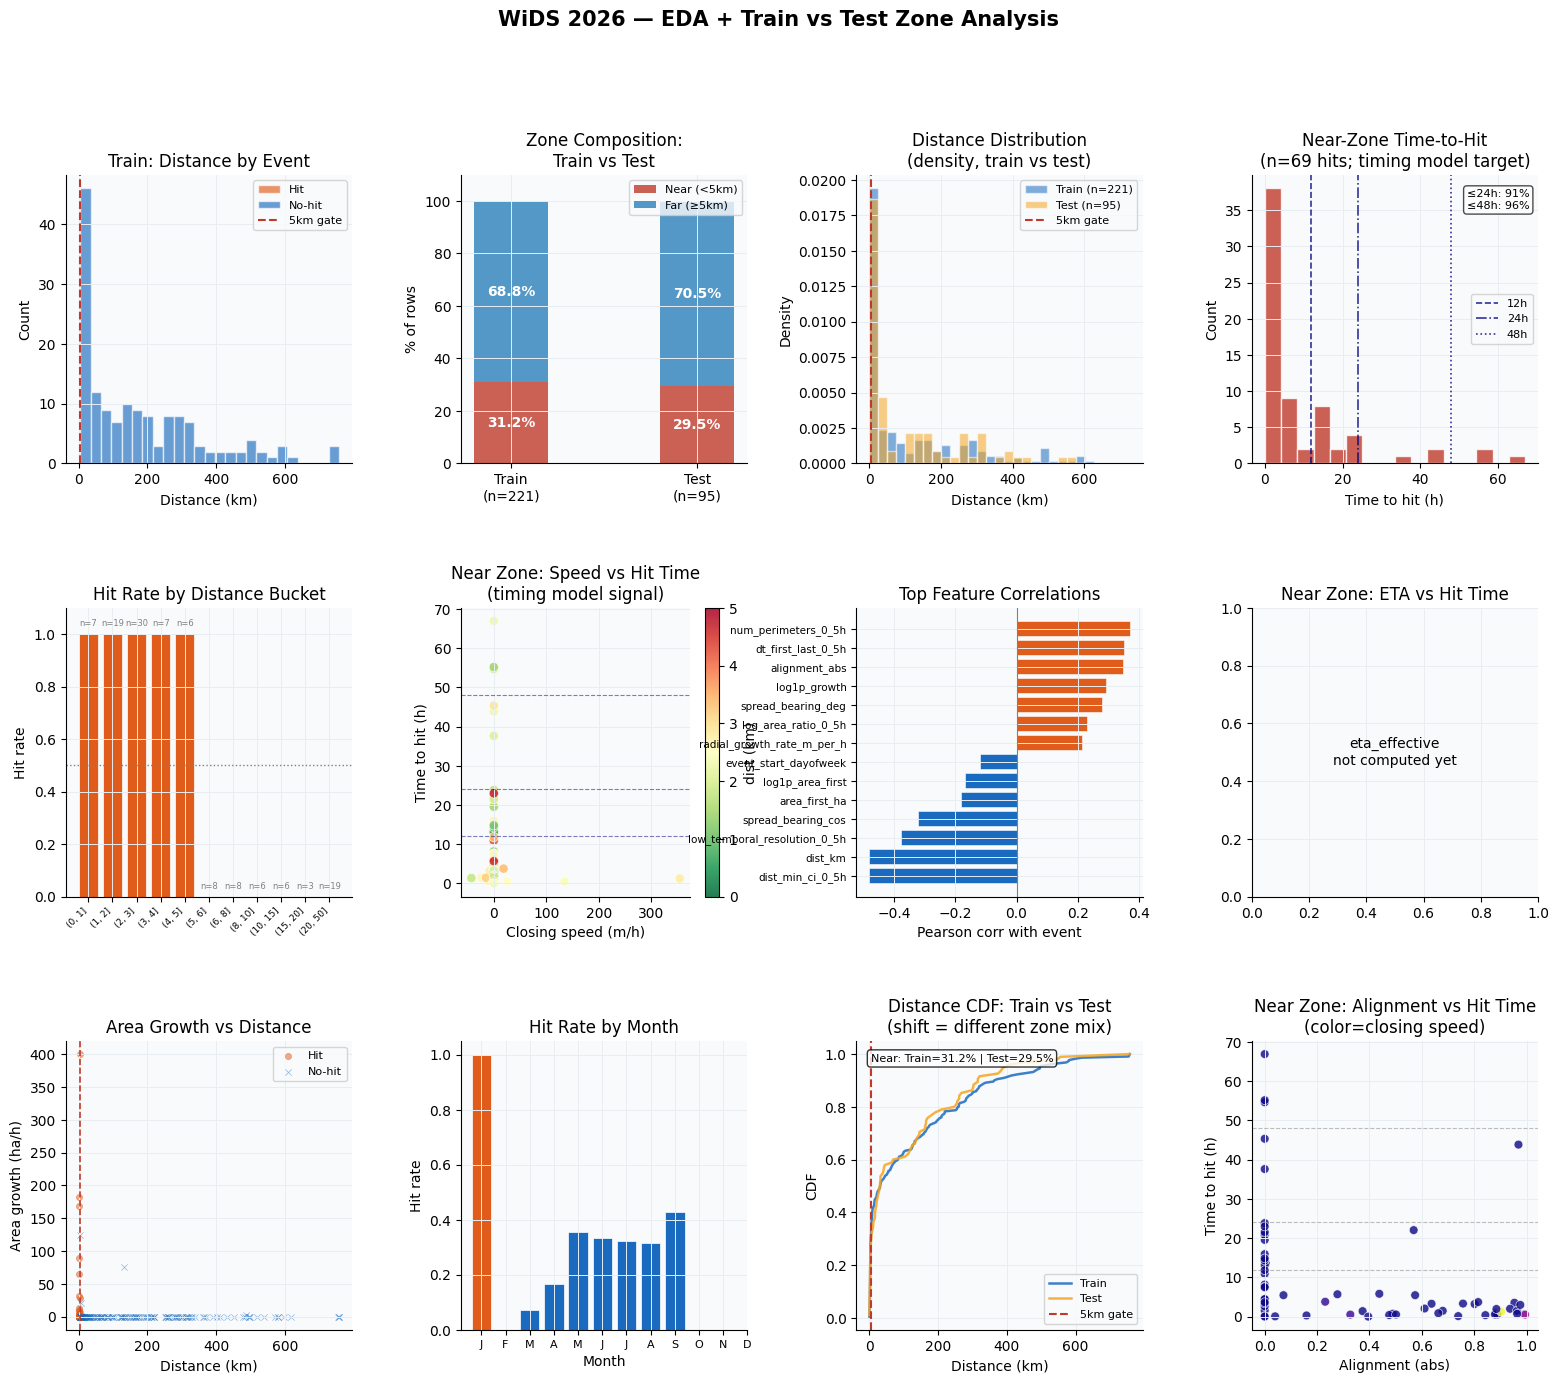


=== Zone Strategy Implication ===
Train: 69/221 near (31.2%) | 152 far (68.8%)
Test:  28/95 near  (29.5%) | 67 far  (70.5%)
Near-zone shift: -1.7% (test has fewer near fires than train)
  ✓ Zone distributions are similar — blend strategy generalizes.

Near-zone hit timing: 91% hit by 24h, 96% by 48h
  → Brier@24 is most sensitive for near-zone; timing model most impactful here.


In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings("ignore")

_train = train_df.copy()
_test  = test_df.copy()
_train["dist_km"] = _train["dist_min_ci_0_5h"] / 1000
_test["dist_km"]  = _test["dist_min_ci_0_5h"]  / 1000
_train["zone"]    = np.where(_train["dist_km"] < 5, "Near (<5km)", "Far (≥5km)")
_test["zone"]     = np.where(_test["dist_km"]  < 5, "Near (<5km)", "Far (≥5km)")

C_NEAR, C_FAR, C_HIT, C_NO = "#c0392b", "#2980b9", "#e05c1a", "#1a6bbf"
plt.rcParams.update({"axes.facecolor":"#f9fafb","figure.facecolor":"white",
                     "axes.grid":True,"grid.color":"#e8edf2","grid.linewidth":0.7,
                     "axes.spines.top":False,"axes.spines.right":False})

fig = plt.figure(figsize=(19, 15))
fig.suptitle("WiDS 2026 — EDA + Train vs Test Zone Analysis", fontsize=15, fontweight="bold", y=0.99)
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)

# ── 1. Distance distribution by event ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0,0])
for ev, lbl, c in [(1,"Hit",C_HIT),(0,"No-hit",C_NO)]:
    ax1.hist(_train.loc[_train.event==ev,"dist_km"], bins=25, alpha=0.65,
             color=c, label=lbl, edgecolor="white", lw=0.4)
ax1.axvline(5, color=C_NEAR, ls="--", lw=1.5, label="5km gate")
ax1.set_xlabel("Distance (km)"); ax1.set_ylabel("Count")
ax1.set_title("Train: Distance by Event"); ax1.legend(fontsize=8)

# ── 2. Train vs Test zone composition (KEY for strategy) ────────────────────
ax2 = fig.add_subplot(gs[0,1])
train_near = (_train.dist_km < 5).sum(); train_far = (_train.dist_km >= 5).sum()
test_near  = (_test.dist_km  < 5).sum(); test_far  = (_test.dist_km  >= 5).sum()
x = [0, 1]
ax2.bar(x, [train_near/len(_train)*100, test_near/len(_test)*100],
        color=C_NEAR, alpha=0.8, label="Near (<5km)", width=0.4)
ax2.bar(x, [train_far/len(_train)*100, test_far/len(_test)*100],
        bottom=[train_near/len(_train)*100, test_near/len(_test)*100],
        color=C_FAR, alpha=0.8, label="Far (≥5km)", width=0.4)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["Train\n(n=221)", f"Test\n(n={len(_test)})"], fontsize=10)
ax2.set_ylabel("% of rows"); ax2.set_title("Zone Composition:\nTrain vs Test")
ax2.set_ylim(0, 110); ax2.legend(fontsize=8)
for xi, (n, tot) in enumerate([(train_near, len(_train)), (test_near, len(_test))]):
    ax2.text(xi, n/tot*100/2, f"{n/tot:.1%}", ha="center", va="center",
             color="white", fontsize=10, fontweight="bold")
    ax2.text(xi, n/tot*100 + (tot-n)/tot*100/2, f"{(tot-n)/tot:.1%}", ha="center",
             va="center", color="white", fontsize=10, fontweight="bold")
print(f"Train zone: Near={train_near} ({train_near/len(_train):.1%}) | Far={train_far} ({train_far/len(_train):.1%})")
print(f"Test  zone: Near={test_near}  ({test_near/len(_test):.1%}) | Far={test_far}  ({test_far/len(_test):.1%})")

# ── 3. Train vs Test distance distribution overlay ───────────────────────────
ax3 = fig.add_subplot(gs[0,2])
bins = np.linspace(0, _train.dist_km.quantile(0.99), 30)
ax3.hist(_train["dist_km"], bins=bins, alpha=0.55, color=C_NO, label=f"Train (n={len(_train)})",
         density=True, edgecolor="white", lw=0.4)
ax3.hist(_test["dist_km"],  bins=bins, alpha=0.55, color="#f5a623", label=f"Test (n={len(_test)})",
         density=True, edgecolor="white", lw=0.4)
ax3.axvline(5, color=C_NEAR, ls="--", lw=1.5, label="5km gate")
ax3.set_xlabel("Distance (km)"); ax3.set_ylabel("Density")
ax3.set_title("Distance Distribution\n(density, train vs test)"); ax3.legend(fontsize=8)

# ── 4. Near-zone: time-to-hit distribution (what timing model targets) ───────
ax4 = fig.add_subplot(gs[0,3])
near_hits = _train[(_train.dist_km < 5) & (_train.event==1)]
ax4.hist(near_hits["time_to_hit_hours"], bins=16, color=C_NEAR, alpha=0.8,
         edgecolor="white", lw=0.4)
for h, ls, lbl in [(12,"--","12h"),(24,"-.","24h"),(48,":","48h")]:
    ax4.axvline(h, color="navy", ls=ls, lw=1.2, label=lbl, alpha=0.8)
ax4.set_xlabel("Time to hit (h)"); ax4.set_ylabel("Count")
ax4.set_title(f"Near-Zone Time-to-Hit\n(n={len(near_hits)} hits; timing model target)")
ax4.legend(fontsize=8)
pct_before_24 = (near_hits.time_to_hit_hours <= 24).mean()
pct_before_48 = (near_hits.time_to_hit_hours <= 48).mean()
ax4.text(0.97, 0.95, f"≤24h: {pct_before_24:.0%}\n≤48h: {pct_before_48:.0%}",
         transform=ax4.transAxes, ha="right", va="top", fontsize=8,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# ── 5. Hit rate by distance bucket ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[1,0])
bins_b = [0,1,2,3,4,5,6,8,10,15,20,50]
_train["dist_bin"] = pd.cut(_train["dist_km"], bins=bins_b)
hr = _train.groupby("dist_bin", observed=True)["event"].agg(["mean","count"]).reset_index()
bars = ax5.bar(range(len(hr)), hr["mean"],
               color=[C_HIT if v>0.5 else C_NO for v in hr["mean"]],
               edgecolor="white", lw=0.5)
ax5.set_xticks(range(len(hr)))
ax5.set_xticklabels([str(b) for b in hr["dist_bin"]], rotation=45, ha="right", fontsize=6.5)
ax5.set_ylabel("Hit rate"); ax5.set_title("Hit Rate by Distance Bucket"); ax5.set_ylim(0,1.1)
ax5.axhline(0.5, color="grey", ls=":", lw=1)
for bar, cnt in zip(bars, hr["count"]):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
             f"n={cnt}", ha="center", fontsize=6, color="grey")

# ── 6. Near-zone: closing speed vs time-to-hit (timing model features) ───────
ax6 = fig.add_subplot(gs[1,1])
sc = ax6.scatter(near_hits["closing_speed_m_per_h"], near_hits["time_to_hit_hours"],
                  c=near_hits["dist_km"], cmap="RdYlGn_r", s=45, alpha=0.85,
                  edgecolors="white", lw=0.5, vmin=0, vmax=5)
plt.colorbar(sc, ax=ax6, label="dist (km)")
for h in [12, 24, 48]: ax6.axhline(h, color="navy", ls="--", lw=0.8, alpha=0.5)
ax6.set_xlabel("Closing speed (m/h)"); ax6.set_ylabel("Time to hit (h)")
ax6.set_title("Near Zone: Speed vs Hit Time\n(timing model signal)")

# ── 7. Feature correlations with event ───────────────────────────────────────
ax7 = fig.add_subplot(gs[1,2])
num_cols = [c for c in _train.select_dtypes(include=np.number).columns
            if c not in ["event_id","event","time_to_hit_hours","dist_bin"]]
corr = _train[num_cols+["event"]].corr()["event"].drop("event").sort_values()
top  = pd.concat([corr.head(7), corr.tail(7)])
ax7.barh(range(len(top)), top.values,
         color=[C_NO if v<0 else C_HIT for v in top.values], edgecolor="white", lw=0.4)
ax7.set_yticks(range(len(top))); ax7.set_yticklabels(top.index, fontsize=7.5)
ax7.axvline(0, color="grey", lw=0.8)
ax7.set_xlabel("Pearson corr with event"); ax7.set_title("Top Feature Correlations")

# ── 8. Near-zone: eta_effective vs time-to-hit ───────────────────────────────
ax8 = fig.add_subplot(gs[1,3])
if "eta_effective" in near_hits.columns:
    ef = near_hits["eta_effective"].clip(0, 200)
    ax8.scatter(ef, near_hits["time_to_hit_hours"],
                c=C_NEAR, alpha=0.7, s=35, edgecolors="white", lw=0.5)
    # Fit a simple line for visual
    m_idx = np.isfinite(ef) & np.isfinite(near_hits["time_to_hit_hours"])
    if m_idx.sum() > 3:
        z = np.polyfit(ef[m_idx], near_hits.loc[m_idx,"time_to_hit_hours"], 1)
        xs = np.linspace(ef.min(), ef.max(), 50)
        ax8.plot(xs, np.polyval(z, xs), color="navy", lw=1.5, ls="--", alpha=0.7)
    for h in [12, 24, 48]: ax8.axhline(h, color="grey", ls="--", lw=0.8, alpha=0.5)
    ax8.set_xlabel("ETA effective (h)"); ax8.set_ylabel("Actual time to hit (h)")
    ax8.set_title("Near Zone: ETA vs Actual Hit Time\n(key timing model predictor)")
else:
    ax8.text(0.5, 0.5, "eta_effective\nnot computed yet", ha="center", va="center",
             transform=ax8.transAxes)
    ax8.set_title("Near Zone: ETA vs Hit Time")

# ── 9. Area growth + closing speed: far zone detection features ──────────────
ax9 = fig.add_subplot(gs[2,0])
for ev, lbl, c, mk in [(1,"Hit",C_HIT,"o"),(0,"No-hit",C_NO,"x")]:
    sub = _train[_train.event==ev]
    ax9.scatter(sub["dist_km"], sub["area_growth_rate_ha_per_h"].clip(0,400),
                c=c, label=lbl, alpha=0.5, s=20, marker=mk, lw=0.5)
ax9.axvline(5, color=C_NEAR, ls="--", lw=1.2)
ax9.set_xlabel("Distance (km)"); ax9.set_ylabel("Area growth (ha/h)")
ax9.set_title("Area Growth vs Distance"); ax9.legend(fontsize=8)

# ── 10. Hit rate by month ────────────────────────────────────────────────────
ax10 = fig.add_subplot(gs[2,1])
mr = _train.groupby("event_start_month")["event"].mean()
ax10.bar(mr.index, mr.values,
         color=[C_HIT if v>0.5 else C_NO for v in mr.values],
         edgecolor="white", lw=0.5)
ax10.set_xlabel("Month"); ax10.set_ylabel("Hit rate"); ax10.set_title("Hit Rate by Month")
ax10.set_xticks(range(1,13))
ax10.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"], fontsize=8)

# ── 11. Test distance CDF vs train ──────────────────────────────────────────
ax11 = fig.add_subplot(gs[2,2])
for df_z, lbl, c in [(_train,"Train",C_NO),(_test,"Test","#f5a623")]:
    sorted_d = np.sort(df_z["dist_km"].values)
    ax11.plot(sorted_d, np.arange(1, len(sorted_d)+1)/len(sorted_d),
              color=c, lw=1.8, label=lbl, alpha=0.85)
ax11.axvline(5, color=C_NEAR, ls="--", lw=1.5, label="5km gate")
ax11.set_xlabel("Distance (km)"); ax11.set_ylabel("CDF")
ax11.set_title("Distance CDF: Train vs Test\n(shift = different zone mix)")
ax11.legend(fontsize=8)
train_pct_near = (_train.dist_km < 5).mean()
test_pct_near  = (_test.dist_km  < 5).mean()
ax11.text(0.05, 0.93, f"Near: Train={train_pct_near:.1%} | Test={test_pct_near:.1%}",
          transform=ax11.transAxes, fontsize=8,
          bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# ── 12. Near-zone alignment vs hit time ─────────────────────────────────────
ax12 = fig.add_subplot(gs[2,3])
ax12.scatter(near_hits["alignment_abs"], near_hits["time_to_hit_hours"],
             c=near_hits["closing_speed_m_per_h"].clip(0, 2000),
             cmap="plasma", s=40, alpha=0.8, edgecolors="white", lw=0.5)
for h in [12, 24, 48]: ax12.axhline(h, color="grey", ls="--", lw=0.8, alpha=0.5)
ax12.set_xlabel("Alignment (abs)"); ax12.set_ylabel("Time to hit (h)")
ax12.set_title("Near Zone: Alignment vs Hit Time\n(color=closing speed)")

plt.savefig("eda_v3.png", dpi=130, bbox_inches="tight"); plt.show()

# ── Zone strategy implication ────────────────────────────────────────────────
print("\n=== Zone Strategy Implication ===")
print(f"Train: {train_near}/{len(_train)} near ({train_near/len(_train):.1%}) | {train_far} far ({train_far/len(_train):.1%})")
print(f"Test:  {test_near}/{len(_test)} near  ({test_near/len(_test):.1%}) | {test_far} far  ({test_far/len(_test):.1%})")
diff = test_pct_near - train_pct_near
print(f"Near-zone shift: {diff:+.1%} (test {'has more' if diff>0 else 'has fewer'} near fires than train)")
if abs(diff) > 0.05:
    print("  ⚠️  Significant zone shift — near-zone model performance matters more for test!")
else:
    print("  ✓ Zone distributions are similar — blend strategy generalizes.")
print(f"\nNear-zone hit timing: {pct_before_24:.0%} hit by 24h, {pct_before_48:.0%} by 48h")
print(f"  → Brier@24 is most sensitive for near-zone; timing model most impactful here.")


## Feature Engineering

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Feature engineering
# Same conservative set as prev series — proven stable
# Added: zone-stratified rank features (within-stratum percentile ranks)
# ─────────────────────────────────────────────────────────────────────────────
def create_features(df: pd.DataFrame, fit_df: pd.DataFrame = None) -> pd.DataFrame:
    """
    fit_df: if provided, rank features are computed relative to fit_df (use train for both train and test).
    """
    ref = fit_df if fit_df is not None else df
    result = df.copy()
    dist       = result["dist_min_ci_0_5h"].clip(lower=1)
    speed      = result["closing_speed_m_per_h"]
    perimeters = result["num_perimeters_0_5h"]
    area_first = result["area_first_ha"]

    # Distance transformations
    result["log_distance"]    = np.log1p(dist)
    result["inv_distance"]    = 1 / (dist / 1000 + 0.1)
    result["inv_distance_sq"] = result["inv_distance"] ** 2
    result["sqrt_distance"]   = np.sqrt(dist)
    result["dist_km"]         = dist / 1000
    result["dist_km_sq"]      = (dist / 1000) ** 2
    result["dist_km_cb"]      = (dist / 1000) ** 3
    result["dist_rank"]       = dist.rank(pct=True)

    # Area-to-distance
    fire_radius               = np.sqrt(area_first * 10000 / np.pi)
    result["fire_radius_km"]  = fire_radius / 1000
    result["radius_to_dist"]  = fire_radius / dist
    result["area_to_dist_ratio"]  = area_first / (dist / 1000 + 0.1)
    result["log_area_dist_ratio"] = np.log1p(area_first) - np.log1p(dist)

    # Kinematics
    result["has_movement"] = (perimeters > 1).astype(float)
    closing_pos = speed.clip(lower=0)
    result["eta_hours"]    = np.where(closing_pos > 0.01, dist / closing_pos, 9999).clip(max=9999)
    result["log_eta"]      = np.log1p(result["eta_hours"].clip(0, 9999))
    radial_growth = result["radial_growth_rate_m_per_h"].clip(lower=0)
    effective_closing = closing_pos + radial_growth
    result["effective_closing_speed"] = effective_closing
    result["eta_effective"]  = np.where(effective_closing > 0.01, dist / effective_closing, 9999).clip(max=9999)
    result["threat_score"]   = result["alignment_abs"] * speed / np.log1p(dist)
    result["threat_score_sq"]= result["threat_score"] ** 2
    result["fire_urgency"]    = perimeters * speed
    result["growth_intensity"]= result["area_growth_rate_ha_per_h"] * perimeters

    # Zones (binary flags)
    result["zone_near"]    = (dist < 5000).astype(float)
    result["zone_warning"] = ((dist >= 5000) & (dist < 10000)).astype(float)
    result["zone_far"]     = (dist >= 10000).astype(float)

    # Zone-stratified rank features (NEW)
    # Rank of speed and threat within the near zone — captures within-zone discrimination
    ref_near_mask = ref["dist_min_ci_0_5h"].clip(lower=1) < 5000
    ref_far_mask  = ~ref_near_mask
    # Near zone speed rank (computed on ref distribution)
    near_speed_ref = ref.loc[ref_near_mask, "closing_speed_m_per_h"].values
    far_threat_ref = (ref.loc[ref_far_mask, "alignment_abs"] *
                      ref.loc[ref_far_mask, "closing_speed_m_per_h"] /
                      np.log1p(ref.loc[ref_far_mask, "dist_min_ci_0_5h"].clip(lower=1))).values

    def rank_against_ref(vals, ref_vals):
        """Percentile rank of each val against ref_vals distribution."""
        return np.array([(ref_vals < v).mean() for v in vals])

    cur_near_mask = dist < 5000
    cur_far_mask  = ~cur_near_mask
    near_speed_rank = np.zeros(len(result))
    far_threat_rank = np.zeros(len(result))
    if cur_near_mask.sum() > 0:
        near_speed_rank[cur_near_mask.values] = rank_against_ref(
            speed[cur_near_mask].values, near_speed_ref)
    if cur_far_mask.sum() > 0:
        threat_cur_far = (result.loc[cur_far_mask, "alignment_abs"] *
                          speed[cur_far_mask] /
                          np.log1p(dist[cur_far_mask])).values
        far_threat_rank[cur_far_mask.values] = rank_against_ref(
            threat_cur_far, far_threat_ref)
    result["near_speed_rank"] = near_speed_rank
    result["far_threat_rank"] = far_threat_rank

    # Temporal
    result["is_summer"]    = result["event_start_month"].isin([6, 7, 8]).astype(float)
    result["is_afternoon"] = ((result["event_start_hour"] >= 12) &
                               (result["event_start_hour"] < 20)).astype(float)

    drop_cols = [
        "relative_growth_0_5h", "projected_advance_m",
        "centroid_displacement_m", "centroid_speed_m_per_h",
        "closing_speed_abs_m_per_h", "area_growth_abs_0_5h",
    ]
    result = result.drop(columns=[c for c in drop_cols if c in result.columns])
    result = result.replace([np.inf, -np.inf], np.nan).fillna(0)
    return result


train_processed = create_features(train_df, fit_df=train_df)
test_processed  = create_features(test_df,  fit_df=train_df)  # rank against train distribution

print("Engineered features:", len([c for c in train_processed.columns
                                    if c not in ["event_id","event","time_to_hit_hours"]]))


Engineered features: 56


## Competition Metric

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Competition metric (proven formula — do NOT change)
# WBrier = 0.3*B24 + 0.4*B48 + 0.3*B72  (verified against LB)
# ─────────────────────────────────────────────────────────────────────────────
def compute_c_index(time, event, risk):
    n = len(time); concordant = comparable = 0
    for i in range(n):
        if event[i] != 1: continue
        for j in range(n):
            if i==j or time[i]>=time[j]: continue
            comparable += 1
            if risk[i] > risk[j]:    concordant += 1
            elif risk[i]==risk[j]:   concordant += 0.5
    return concordant/comparable if comparable > 0 else 0.5

def compute_brier(time, event, prob, horizon):
    valid  = ~((event==0) & (time<horizon))
    if valid.sum() == 0: return 0.25
    y_true = ((event==1) & (time<=horizon)).astype(float)[valid]
    return float(np.mean((np.clip(prob[valid],0,1) - y_true)**2))

def compute_hybrid_score(time, event, p24, p48, p72):
    risk  = 0.3*p24 + 0.4*p48 + 0.3*p72
    c_idx = compute_c_index(time, event, risk)
    b24 = compute_brier(time, event, p24, 24)
    b48 = compute_brier(time, event, p48, 48)
    b72 = compute_brier(time, event, p72, 72)
    wb  = 0.3*b24 + 0.4*b48 + 0.3*b72
    return 0.3*c_idx + 0.7*(1-wb), c_idx, wb

def enforce_monotonicity(preds):
    result = np.clip(preds, 0, 1)
    for i in range(1, result.shape[1]):
        result[:,i] = np.maximum(result[:,i], result[:,i-1])
    return result

def get_surv_predictions(model, X):
    surv_fns = model.predict_survival_function(X)
    preds = np.empty((len(surv_fns), len(HORIZONS_PRED)), dtype=float)
    for i, fn in enumerate(surv_fns):
        t_min, t_max = fn.domain
        preds[i,:] = fn(np.clip(HORIZONS_PRED, t_min, t_max))
    return 1.0 - preds

def make_binary_target(time_vals, event_vals, horizon):
    unknown = (event_vals==0) & (time_vals<horizon)
    y = ((event_vals==1) & (time_vals<=horizon)).astype(float)
    return y, ~unknown

def compute_ipcw_weights(times, events, horizon):
    unique_t = np.sort(np.unique(times)); surv = np.ones(len(unique_t))
    for i, t in enumerate(unique_t):
        at_risk = (times>=t).sum()
        cens = ((times==t) & (events==0)).sum()
        if at_risk > 0: surv[i] = 1 - cens/at_risk
        if i > 0: surv[i] *= surv[i-1]
    def G(t):
        idx = np.searchsorted(unique_t, t, side="right")-1
        return max(surv[idx], 0.01) if idx >= 0 else 1.0
    weights = np.ones(len(times))
    for i in range(len(times)):
        if events[i]==1 and times[i]<=horizon:   weights[i] = 1.0/G(times[i])
        elif times[i]>=horizon:                   weights[i] = 1.0/G(horizon)
    return weights

# Shared survival data
y_surv       = Surv.from_arrays(event=train_df["event"].astype(bool),
                                  time=train_df["time_to_hit_hours"])
event_values = train_df["event"].values
time_values  = train_df["time_to_hit_hours"].values
dist_train   = train_df["dist_min_ci_0_5h"].values
dist_test    = test_df["dist_min_ci_0_5h"].values
near_train   = dist_train < STRAT_THR
near_test    = dist_test  < STRAT_THR

print(f"Survival structure: {y_surv.shape} | Near train: {near_train.sum()} | Far train: {(~near_train).sum()}")


Survival structure: (221,) | Near train: 69 | Far train: 152


## Model 1 — GBSA Survival Ensemble

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 1: GBSA Survival Ensemble (10 configs, 40 seeds, 5-fold CV-bag)
# Uses raw features — proven best in previous series
# ─────────────────────────────────────────────────────────────────────────────
X_gbsa_train = train_df.drop(columns=["event_id","event","time_to_hit_hours"])
X_gbsa_test  = test_df.drop(columns=["event_id"])

gbsa_configs = [
    {"learning_rate":0.01,  "subsample":0.70, "max_depth":3, "min_samples_leaf":12, "min_samples_split":3, "n_estimators":1200, "dropout_rate":0.0},
    {"learning_rate":0.01,  "subsample":0.85, "max_depth":3, "min_samples_leaf":15, "min_samples_split":3, "n_estimators":1200, "dropout_rate":0.0},
    {"learning_rate":0.01,  "subsample":0.60, "max_depth":3, "min_samples_leaf":12, "min_samples_split":3, "n_estimators":1200, "dropout_rate":0.0},
    {"learning_rate":0.005, "subsample":0.85, "max_depth":3, "min_samples_leaf":12, "min_samples_split":3, "n_estimators":2000, "dropout_rate":0.0},
    {"learning_rate":0.01,  "subsample":0.85, "max_depth":3, "min_samples_leaf":20, "min_samples_split":3, "n_estimators":1400, "dropout_rate":0.0},
    {"learning_rate":0.008, "subsample":0.75, "max_depth":2, "min_samples_leaf":15, "min_samples_split":4, "n_estimators":1500, "dropout_rate":0.0},
    {"learning_rate":0.015, "subsample":0.70, "max_depth":3, "min_samples_leaf":10, "min_samples_split":3, "n_estimators":1000, "dropout_rate":0.0},
    {"learning_rate":0.005, "subsample":0.90, "max_depth":3, "min_samples_leaf":18, "min_samples_split":5, "n_estimators":2500, "dropout_rate":0.0},
    {"learning_rate":0.01,  "subsample":0.80, "max_depth":4, "min_samples_leaf":12, "min_samples_split":3, "n_estimators":1200, "dropout_rate":0.0},
    {"learning_rate":0.02,  "subsample":0.65, "max_depth":3, "min_samples_leaf":10, "min_samples_split":3, "n_estimators":800,  "dropout_rate":0.0},
]

GBSA_SEEDS = GBSA_SEEDS_FULL if RUN_MODE=="full" else GBSA_SEEDS_FAST

oof_gbsa  = np.zeros((len(X_gbsa_train), 4)) if DO_OOF else None
test_gbsa = np.zeros((len(X_gbsa_test), 4))

print(f"GBSA: {len(gbsa_configs)} configs × {len(GBSA_SEEDS)} seeds × 5-fold CV-bag")
for cfg_idx, cfg in enumerate(gbsa_configs, 1):
    cfg_oof  = np.zeros((len(X_gbsa_train), 4)) if DO_OOF else None
    cfg_test = np.zeros((len(X_gbsa_test), 4))
    for seed in GBSA_SEEDS:
        seed_oof  = np.zeros((len(X_gbsa_train), 4)) if DO_OOF else None
        seed_test = np.zeros((len(X_gbsa_test), 4))
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr_idx, va_idx in cv.split(X_gbsa_train, event_values):
            m = GradientBoostingSurvivalAnalysis(**{**cfg, "random_state": seed})
            m.fit(X_gbsa_train.iloc[tr_idx], y_surv[tr_idx])
            if DO_OOF:
                seed_oof[va_idx] = get_surv_predictions(m, X_gbsa_train.iloc[va_idx])
            if CV_BAG_TEST:
                seed_test += get_surv_predictions(m, X_gbsa_test) / 5
        if DO_OOF:      cfg_oof  += seed_oof  / len(GBSA_SEEDS)
        if CV_BAG_TEST: cfg_test += seed_test / len(GBSA_SEEDS)
        else:
            mf = GradientBoostingSurvivalAnalysis(**{**cfg, "random_state": seed})
            mf.fit(X_gbsa_train, y_surv)
            cfg_test += get_surv_predictions(mf, X_gbsa_test) / len(GBSA_SEEDS)
    if DO_OOF: oof_gbsa  += cfg_oof  / len(gbsa_configs)
    test_gbsa += cfg_test / len(gbsa_configs)
    print(f"  cfg {cfg_idx}/{len(gbsa_configs)} done (n={cfg['n_estimators']}, ss={cfg['subsample']})")

oof_gbsa_raw  = oof_gbsa.copy() if DO_OOF else None
test_gbsa_raw = test_gbsa.copy()
print("GBSA done.")


GBSA: 10 configs × 40 seeds × 5-fold CV-bag
  cfg 1/10 done (n=1200, ss=0.7)
  cfg 2/10 done (n=1200, ss=0.85)
  cfg 3/10 done (n=1200, ss=0.6)
  cfg 4/10 done (n=2000, ss=0.85)
  cfg 5/10 done (n=1400, ss=0.85)
  cfg 6/10 done (n=1500, ss=0.75)
  cfg 7/10 done (n=1000, ss=0.7)
  cfg 8/10 done (n=2500, ss=0.9)
  cfg 9/10 done (n=1200, ss=0.8)
  cfg 10/10 done (n=800, ss=0.65)
GBSA done.


## Model 2 — CoxPH Survival Ensemble

_20 seeds × 7 alphas. Unchanged from v4._

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 2: CoxPH Survival Ensemble
# v4: 20 seeds (up from 10), 7 alpha values (up from 5, added 0.001 and 2.0)
# CoxPH OOF B@24=0.027 = matches GBSA → strong linear signal, increasing weight.
# ─────────────────────────────────────────────────────────────────────────────
COX_FEATURES_LIST_ENG = [
    "dist_km", "log_distance", "inv_distance",
    "closing_speed_m_per_h", "radial_growth_rate_m_per_h",
    "alignment_abs", "threat_score", "log_eta", "eta_effective",
    "area_to_dist_ratio", "fire_radius_km",
    "num_perimeters_0_5h", "has_movement",
    "near_speed_rank", "far_threat_rank",
    "is_summer", "is_afternoon",
    "zone_near", "zone_far",
]

X_cox_train = train_processed[[c for c in COX_FEATURES_LIST_ENG if c in train_processed.columns]].copy()
X_cox_test  = test_processed[[c for c in COX_FEATURES_LIST_ENG if c in test_processed.columns]].copy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_cox_train_sc = pd.DataFrame(scaler.fit_transform(X_cox_train),
                                columns=X_cox_train.columns, index=X_cox_train.index)
X_cox_test_sc  = pd.DataFrame(scaler.transform(X_cox_test),
                                columns=X_cox_test.columns,  index=X_cox_test.index)

# v4: wider alpha range for more diversity
cox_alphas = [0.001, 0.01, 0.05, 0.10, 0.50, 1.00, 2.00]

COX_SEEDS = COX_SEEDS_FULL if RUN_MODE=="full" else COX_SEEDS_FAST

oof_cox  = np.zeros((len(X_cox_train_sc), 4)) if DO_OOF else None
test_cox = np.zeros((len(X_cox_test_sc), 4))

print(f"CoxPH v4: {len(cox_alphas)} alphas × {len(COX_SEEDS)} seeds × 5-fold CV-bag")
print(f"  Features: {X_cox_train_sc.shape[1]} | alphas: {cox_alphas}")
for alpha_idx, alpha in enumerate(cox_alphas, 1):
    alpha_oof  = np.zeros((len(X_cox_train_sc), 4)) if DO_OOF else None
    alpha_test = np.zeros((len(X_cox_test_sc), 4))
    for seed in COX_SEEDS:
        seed_oof  = np.zeros((len(X_cox_train_sc), 4)) if DO_OOF else None
        seed_test = np.zeros((len(X_cox_test_sc), 4))
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr_idx, va_idx in cv.split(X_cox_train_sc, event_values):
            m = CoxPHSurvivalAnalysis(alpha=alpha)
            try:
                m.fit(X_cox_train_sc.iloc[tr_idx], y_surv[tr_idx])
                if DO_OOF:
                    seed_oof[va_idx] = get_surv_predictions(m, X_cox_train_sc.iloc[va_idx])
                if CV_BAG_TEST:
                    seed_test += get_surv_predictions(m, X_cox_test_sc) / 5
            except Exception as e:
                if DO_OOF: seed_oof[va_idx] = 0.5
                if CV_BAG_TEST: seed_test += 0.5 / 5
        if DO_OOF:      alpha_oof  += seed_oof  / len(COX_SEEDS)
        if CV_BAG_TEST: alpha_test += seed_test / len(COX_SEEDS)
        else:
            mf = CoxPHSurvivalAnalysis(alpha=alpha)
            try:
                mf.fit(X_cox_train_sc, y_surv)
                alpha_test += get_surv_predictions(mf, X_cox_test_sc) / len(COX_SEEDS)
            except: alpha_test += 0.5 / len(COX_SEEDS)
    if DO_OOF: oof_cox  += alpha_oof  / len(cox_alphas)
    test_cox += alpha_test / len(cox_alphas)
    print(f"  alpha={alpha} done")

print("CoxPH done.")
if DO_OOF:
    b24_cox = compute_brier(time_values, event_values, np.clip(oof_cox[:,1],0,1), 24)
    b48_cox = compute_brier(time_values, event_values, np.clip(oof_cox[:,2],0,1), 48)
    print(f"  CoxPH OOF B@24={b24_cox:.5f}  B@48={b48_cox:.5f}  (v3 was B24=0.02653)")


CoxPH v4: 7 alphas × 20 seeds × 5-fold CV-bag
  Features: 19 | alphas: [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
  alpha=0.001 done
  alpha=0.01 done
  alpha=0.05 done
  alpha=0.1 done
  alpha=0.5 done
  alpha=1.0 done
  alpha=2.0 done
CoxPH done.
  CoxPH OOF B@24=0.02724  B@48=0.01614  (v3 was B24=0.02653)


## Model 3 — Random Survival Forest

_15 seeds × 3 configs. Unchanged from v4._

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 3: Random Survival Forest
# v4: 15 seeds (up from 5) to stabilize the now-reduced weight.
# RSF OOF B@24=0.070 (poor individually but adds bagging diversity).
# Weight reduced in blend to reflect its poor individual performance.
# ─────────────────────────────────────────────────────────────────────────────
X_rsf_train = train_df.drop(columns=["event_id","event","time_to_hit_hours"])
X_rsf_test  = test_df.drop(columns=["event_id"])

rsf_configs = [
    {"n_estimators": 200, "min_samples_leaf": 12, "max_features": "sqrt", "max_depth": None},
    {"n_estimators": 200, "min_samples_leaf": 18, "max_features": "sqrt", "max_depth": None},
    {"n_estimators": 200, "min_samples_leaf": 12, "max_features": 0.5,    "max_depth": 5},
]

RSF_SEEDS = RSF_SEEDS_FULL if RUN_MODE=="full" else RSF_SEEDS_FAST

oof_rsf  = np.zeros((len(X_rsf_train), 4)) if DO_OOF else None
test_rsf = np.zeros((len(X_rsf_test), 4))

print(f"RSF v4: {len(rsf_configs)} configs × {len(RSF_SEEDS)} seeds × 5-fold CV-bag")
for cfg_idx, cfg in enumerate(rsf_configs, 1):
    cfg_oof  = np.zeros((len(X_rsf_train), 4)) if DO_OOF else None
    cfg_test = np.zeros((len(X_rsf_test), 4))
    for seed in RSF_SEEDS:
        seed_oof  = np.zeros((len(X_rsf_train), 4)) if DO_OOF else None
        seed_test = np.zeros((len(X_rsf_test), 4))
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr_idx, va_idx in cv.split(X_rsf_train, event_values):
            m = RandomSurvivalForest(**{**cfg, "random_state": seed, "n_jobs": -1})
            m.fit(X_rsf_train.iloc[tr_idx], y_surv[tr_idx])
            if DO_OOF:
                seed_oof[va_idx] = get_surv_predictions(m, X_rsf_train.iloc[va_idx])
            if CV_BAG_TEST:
                seed_test += get_surv_predictions(m, X_rsf_test) / 5
        if DO_OOF:      cfg_oof  += seed_oof  / len(RSF_SEEDS)
        if CV_BAG_TEST: cfg_test += seed_test / len(RSF_SEEDS)
        else:
            mf = RandomSurvivalForest(**{**cfg, "random_state": seed, "n_jobs": -1})
            mf.fit(X_rsf_train, y_surv)
            cfg_test += get_surv_predictions(mf, X_rsf_test) / len(RSF_SEEDS)
    if DO_OOF: oof_rsf  += cfg_oof  / len(rsf_configs)
    test_rsf += cfg_test / len(rsf_configs)
    print(f"  cfg {cfg_idx}/{len(rsf_configs)} done (n={cfg['n_estimators']}, leaf={cfg['min_samples_leaf']})")

print("RSF done.")
if DO_OOF:
    b24_rsf = compute_brier(time_values, event_values, np.clip(oof_rsf[:,1],0,1), 24)
    b48_rsf = compute_brier(time_values, event_values, np.clip(oof_rsf[:,2],0,1), 48)
    print(f"  RSF OOF B@24={b24_rsf:.5f}  B@48={b48_rsf:.5f}  (v3 was B24=0.07043)")
    print(f"  Note: RSF weight is intentionally low (v4: 0.02-0.06). Higher seeds reduce its noise.")


RSF v4: 3 configs × 15 seeds × 5-fold CV-bag
  cfg 1/3 done (n=200, leaf=12)
  cfg 2/3 done (n=200, leaf=18)
  cfg 3/3 done (n=200, leaf=12)
RSF done.
  RSF OOF B@24=0.07053  B@48=0.06723  (v3 was B24=0.07043)
  Note: RSF weight is intentionally low (v4: 0.02-0.06). Higher seeds reduce its noise.


## Near-Zone Timing Model (Diagnostics — Weight=0.0)

_sigma=1.97 stable. Not useful until sigma < 0.8._

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Near-Zone Timing Model — DIAGNOSTIC ONLY (weight=0.0 in blend)
# Kept for insight: sigma tells us how uncertain near-zone timing is.
# v3 finding: sigma=1.96, B@24=0.081 > constant 0.079 → model hurts.
# ─────────────────────────────────────────────────────────────────────────────
from scipy import stats as scipy_stats
import lightgbm as lgb

TIMING_FEATURES = [
    "closing_speed_m_per_h", "radial_growth_rate_m_per_h",
    "alignment_abs", "num_perimeters_0_5h", "area_growth_rate_ha_per_h",
    "eta_effective", "log_eta", "dist_km", "threat_score",
    "near_speed_rank", "event_start_hour", "is_afternoon", "fire_urgency",
    "area_first_ha", "fire_radius_km",
]

near_hit_mask = (dist_train < STRAT_THR) & (event_values == 1)
near_hit_idx  = np.where(near_hit_mask)[0]   # array of indices
n_near_hits   = len(near_hit_idx)             # FIX: was .sum() which summed index values

near_all_mask  = dist_train < STRAT_THR
near_test_mask = dist_test  < STRAT_THR

print(f"Near-zone hits for timing diagnostics: {n_near_hits} / {near_all_mask.sum()} near train")
print(f"Near-zone test samples: {near_test_mask.sum()}")

avail_timing = [f for f in TIMING_FEATURES if f in train_processed.columns]
X_timing_full = train_processed[avail_timing].values
X_timing_test = test_processed[[f for f in avail_timing if f in test_processed.columns]].values
y_timing_log  = np.log(time_values[near_hit_mask] + 1e-6)

timing_lgb_cfg = {
    "max_depth": 2, "learning_rate": 0.05, "n_estimators": 150,
    "subsample": 0.8, "colsample_bytree": 0.8, "min_child_samples": 4,
    "reg_alpha": 1.0, "reg_lambda": 2.0, "num_leaves": 4,
}
TIMING_SEEDS = (123, 456, 789, 777, 666, 1511, 1523, 2025, 2026, 2033,
                279, 239, 70, 77, 31) if RUN_MODE == "full" else (123, 456, 789)

oof_timing_log_accum = np.zeros(len(train_processed))
oof_timing_log_count = np.zeros(len(train_processed))
all_test_timing_log  = np.zeros(near_test_mask.sum())
all_oof_residuals    = []

for seed in TIMING_SEEDS:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for tr_v, va_v in cv.split(near_hit_idx, np.zeros(len(near_hit_idx))):
        tr_near, va_near = near_hit_idx[tr_v], near_hit_idx[va_v]
        m = lgb.LGBMRegressor(**timing_lgb_cfg, random_state=seed, verbose=-1)
        m.fit(X_timing_full[tr_near], y_timing_log[tr_v])
        pred_va = m.predict(X_timing_full[va_near])
        oof_timing_log_accum[va_near] += pred_va
        oof_timing_log_count[va_near] += 1
        all_oof_residuals.extend((y_timing_log[va_v] - pred_va).tolist())
    mf = lgb.LGBMRegressor(**timing_lgb_cfg, random_state=seed, verbose=-1)
    mf.fit(X_timing_full[near_hit_idx], y_timing_log)
    all_test_timing_log += mf.predict(X_timing_test[near_test_mask]) / len(TIMING_SEEDS)

valid_oof = oof_timing_log_count > 0
oof_timing_log_avg = np.where(valid_oof, oof_timing_log_accum / np.maximum(oof_timing_log_count, 1), 0)
timing_sigma = max(np.std(all_oof_residuals) if len(all_oof_residuals) > 5 else 0.5, 0.2)

def lognormal_horizon_prob(t_hat_log, sigma, horizons):
    probs = []
    for h in horizons:
        z = (np.log(h + 1e-6) - t_hat_log) / (sigma + 1e-8)
        probs.append(scipy_stats.norm.cdf(z))
    return np.stack(probs, axis=1)

HORIZONS_TIMING = [12, 24, 48]
oof_timing_probs  = np.zeros((len(train_processed), 3))
test_timing_probs = np.zeros((len(test_df), 3))

if valid_oof[near_hit_idx].any():
    oof_timing_probs[near_hit_idx] = lognormal_horizon_prob(
        oof_timing_log_avg[near_hit_idx], timing_sigma, HORIZONS_TIMING)
if near_test_mask.sum() > 0:
    test_timing_probs[near_test_mask] = lognormal_horizon_prob(
        all_test_timing_log, timing_sigma, HORIZONS_TIMING)

print(f"\nTiming model DIAGNOSTICS (weight=0.0 in blend):")
print(f"  Sigma (log-space): {timing_sigma:.4f}  (v3 was 1.9611)")
print(f"  ±{timing_sigma:.2f} log-hours = ×{np.exp(timing_sigma):.2f}/÷{np.exp(timing_sigma):.2f} in time")
if DO_OOF and valid_oof[near_hit_idx].any():
    b12 = compute_brier(time_values[near_hit_idx], event_values[near_hit_idx],
                         oof_timing_probs[near_hit_idx,0], 12)
    b24 = compute_brier(time_values[near_hit_idx], event_values[near_hit_idx],
                         oof_timing_probs[near_hit_idx,1], 24)
    print(f"  Timing B@12={b12:.5f}  B@24={b24:.5f}  (v3 was B12=0.17094 B24=0.08147)")
    print(f"  Constant-pred B@24 ≈ {((time_values[near_hit_idx]<=24).mean() - 1)**2 * (time_values[near_hit_idx]<=24).mean() + (time_values[near_hit_idx]<=24).mean()**2 * (1-(time_values[near_hit_idx]<=24).mean()):.5f}")
    if timing_sigma < 1.5:
        print("  → Sigma improved! Consider setting TIMING_MODEL_WEIGHT=0.05 to test.")
    else:
        print("  → Sigma still high. Keep weight=0.0.")


Near-zone hits for timing diagnostics: 69 / 69 near train
Near-zone test samples: 28

Timing model DIAGNOSTICS (weight=0.0 in blend):
  Sigma (log-space): 1.9677  (v3 was 1.9611)
  ±1.97 log-hours = ×7.15/÷7.15 in time
  Timing B@12=0.17110  B@24=0.08173  (v3 was B12=0.17094 B24=0.08147)
  Constant-pred B@24 ≈ 0.07940
  → Sigma still high. Keep weight=0.0.


## Zone-Split LGB IPCW Calibrators

_Unchanged._

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Zone-Split LGB IPCW Calibrators (24h, 48h)
# v4: same architecture as v3, weights updated in blend.
# Near 12h: NearLGB gets 0.10 weight (most uncertain horizon: 63% hit by 12h).
# Near-zone LGB: timing-focused features
# Far-zone LGB:  detection-focused features (conservative)
# ─────────────────────────────────────────────────────────────────────────────
NEAR_LGB_FEATURES = [
    "closing_speed_m_per_h", "radial_growth_rate_m_per_h",
    "alignment_abs", "num_perimeters_0_5h", "area_growth_rate_ha_per_h",
    "eta_effective", "log_eta", "dist_km", "threat_score",
    "near_speed_rank", "event_start_hour", "is_afternoon", "fire_urgency",
    "area_first_ha", "fire_radius_km",
]
FAR_LGB_FEATURES = [
    "dist_km", "log_distance", "inv_distance",
    "closing_speed_m_per_h", "alignment_abs",
    "threat_score", "log_eta", "eta_effective",
    "area_to_dist_ratio", "num_perimeters_0_5h",
    "far_threat_rank", "is_summer", "zone_far",
]

avail_near_lgb = [f for f in NEAR_LGB_FEATURES if f in train_processed.columns]
avail_far_lgb  = [f for f in FAR_LGB_FEATURES  if f in train_processed.columns]

X_near_lgb_train = train_processed[avail_near_lgb]
X_near_lgb_test  = test_processed[[f for f in avail_near_lgb if f in test_processed.columns]]
X_far_lgb_train  = train_processed[avail_far_lgb]
X_far_lgb_test   = test_processed[[f for f in avail_far_lgb if f in test_processed.columns]]

near_lgb_cfgs = {
    24: {"max_depth":2, "learning_rate":0.04, "n_estimators":200,
         "subsample":0.8, "colsample_bytree":0.8, "min_child_samples":4,
         "reg_alpha":0.5, "reg_lambda":1.5, "num_leaves":4},
    48: {"max_depth":2, "learning_rate":0.05, "n_estimators":150,
         "subsample":0.8, "colsample_bytree":0.8, "min_child_samples":3,
         "reg_alpha":0.3, "reg_lambda":1.0, "num_leaves":4},
}
far_lgb_cfgs = {
    24: {"max_depth":2, "learning_rate":0.03, "n_estimators":200,
         "subsample":0.7, "colsample_bytree":0.7, "min_child_samples":8,
         "reg_alpha":1.0, "reg_lambda":3.0, "num_leaves":4},
    48: {"max_depth":2, "learning_rate":0.05, "n_estimators":150,
         "subsample":0.8, "colsample_bytree":0.8, "min_child_samples":6,
         "reg_alpha":0.5, "reg_lambda":2.0, "num_leaves":4},
}

LGB_NEAR_SEEDS = LGB_NEAR_SEEDS_FULL if RUN_MODE=="full" else LGB_NEAR_SEEDS_FAST
LGB_FAR_SEEDS  = LGB_FAR_SEEDS_FULL  if RUN_MODE=="full" else LGB_FAR_SEEDS_FAST
lgb_near_oof, lgb_near_test = {}, {}
lgb_far_oof,  lgb_far_test  = {}, {}

print(f"Zone-Split LGB v4: {len(LGB_NEAR_SEEDS)} near seeds | {len(LGB_FAR_SEEDS)} far seeds")
print(f"  Near features: {len(avail_near_lgb)} | Far features: {len(avail_far_lgb)}")

for horizon in [24, 48]:
    y_bin, mask = make_binary_target(time_values, event_values, horizon)
    valid_idx   = np.where(mask)[0]
    for zone, cfg_d, X_tr, X_te, seeds, oof_d, test_d in [
        ("near", near_lgb_cfgs, X_near_lgb_train, X_near_lgb_test, LGB_NEAR_SEEDS, lgb_near_oof, lgb_near_test),
        ("far",  far_lgb_cfgs,  X_far_lgb_train,  X_far_lgb_test,  LGB_FAR_SEEDS,  lgb_far_oof,  lgb_far_test),
    ]:
        cfg      = cfg_d[horizon]
        all_oof  = np.zeros(len(X_tr))
        all_test = np.zeros(len(X_te))
        for seed in seeds:
            seed_oof = np.zeros(len(X_tr)); last_m = None
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
            for tr_v, va_v in cv.split(valid_idx, y_bin[mask]):
                tr_idx, va_idx = valid_idx[tr_v], valid_idx[va_v]
                ipcw_w = compute_ipcw_weights(time_values[tr_idx], event_values[tr_idx], horizon)
                m = lgb.LGBMClassifier(**cfg, objective="binary", random_state=seed, verbose=-1)
                m.fit(X_tr.iloc[tr_idx], y_bin[tr_idx], sample_weight=ipcw_w)
                seed_oof[va_idx] = m.predict_proba(X_tr.iloc[va_idx])[:,1]; last_m = m
            cens_idx = np.where(~mask)[0]
            if len(cens_idx)>0 and last_m is not None:
                seed_oof[cens_idx] = last_m.predict_proba(X_tr.iloc[cens_idx])[:,1]
            all_oof += seed_oof
            ipcw_w_full = compute_ipcw_weights(time_values[valid_idx], event_values[valid_idx], horizon)
            mf = lgb.LGBMClassifier(**cfg, objective="binary", random_state=seed, verbose=-1)
            mf.fit(X_tr.iloc[valid_idx], y_bin[valid_idx], sample_weight=ipcw_w_full)
            all_test += mf.predict_proba(X_te)[:,1]
        oof_d[horizon]  = all_oof  / len(seeds)
        test_d[horizon] = all_test / len(seeds)
    b_near = compute_brier(time_values, event_values, np.clip(lgb_near_oof[horizon],0,1), horizon)
    b_far  = compute_brier(time_values, event_values, np.clip(lgb_far_oof[horizon],0,1),  horizon)
    print(f"  {horizon}h → Near-LGB B={b_near:.5f} | Far-LGB B={b_far:.5f}")

print("Zone-split LGB done.")


Zone-Split LGB v4: 30 near seeds | 30 far seeds
  Near features: 15 | Far features: 13
  24h → Near-LGB B=0.03136 | Far-LGB B=0.02825
  48h → Near-LGB B=0.02075 | Far-LGB B=0.01493
Zone-split LGB done.


## Blend + Submission (v6)

**Near-zone weights REVERTED to v4** (best LB=0.97167). Locked permanently.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Blend + Submission (v6) — near weights reverted to v4
# ─────────────────────────────────────────────────────────────────────────────
def blend_zone(gbsa, cox, rsf, lgb_p, timing_p, wg, wc, wr, wl, wt=0.0):
    return wg*gbsa + wc*cox + wr*rsf + wl*lgb_p + wt*timing_p

def zone_blend_h(gbsa, cox, rsf, lgb_near_p, lgb_far_p, timing_p, near_mask,
                  wg_n, wc_n, wr_n, wl_n, wt_n, wg_f, wc_f, wr_f, wl_f):
    near = blend_zone(gbsa, cox, rsf, lgb_near_p, timing_p, wg_n, wc_n, wr_n, wl_n, wt_n)
    far  = blend_zone(gbsa, cox, rsf, lgb_far_p,  timing_p, wg_f, wc_f, wr_f, wl_f, 0.0)
    return np.where(near_mask, near, far)

oof_gbsa  = oof_gbsa_raw.copy() if DO_OOF else None
test_gbsa = test_gbsa_raw.copy()
if POWER_CAL_24 != 1.0:
    if DO_OOF: oof_gbsa[:,1] = np.clip(oof_gbsa[:,1] ** POWER_CAL_24, 0, 1)
    test_gbsa[:,1] = np.clip(test_gbsa[:,1] ** POWER_CAL_24, 0, 1)

if DO_OOF:
    oof_blend = np.zeros_like(oof_gbsa)
    oof_blend[:,0] = zone_blend_h(
        oof_gbsa[:,0], oof_cox[:,0], oof_rsf[:,0],
        lgb_near_oof[24], lgb_far_oof[24], oof_timing_probs[:,0], near_train,
        W_GBSA_NEAR_12, W_COX_NEAR_12, W_RSF_NEAR_12, W_LGB_NEAR_12, 0.0,
        1.0, 0.0, 0.0, 0.0)
    oof_blend[:,1] = zone_blend_h(
        oof_gbsa[:,1], oof_cox[:,1], oof_rsf[:,1],
        lgb_near_oof[24], lgb_far_oof[24], oof_timing_probs[:,1], near_train,
        W_GBSA_NEAR_24, W_COX_NEAR_24, W_RSF_NEAR_24, W_LGB_NEAR_24, 0.0,
        W_GBSA_FAR_24,  W_COX_FAR_24,  W_RSF_FAR_24,  W_LGB_FAR_24)
    oof_blend[:,2] = zone_blend_h(
        oof_gbsa[:,2], oof_cox[:,2], oof_rsf[:,2],
        lgb_near_oof[48], lgb_far_oof[48], oof_timing_probs[:,2], near_train,
        W_GBSA_NEAR_48, W_COX_NEAR_48, W_RSF_NEAR_48, W_LGB_NEAR_48, 0.0,
        W_GBSA_FAR_48,  W_COX_FAR_48,  W_RSF_FAR_48,  W_LGB_FAR_48)
    oof_blend[:,3] = 1.0
    oof_final = enforce_monotonicity(oof_blend)
    hybrid, c_idx, wb = compute_hybrid_score(
        time_values, event_values, oof_final[:,1], oof_final[:,2], oof_final[:,3])
    b12 = compute_brier(time_values, event_values, oof_final[:,0], 12)
    b24 = compute_brier(time_values, event_values, oof_final[:,1], 24)
    b48 = compute_brier(time_values, event_values, oof_final[:,2], 48)
    print(f"OOF Hybrid: {hybrid:.5f}  C-Index: {c_idx:.4f}  WBrier: {wb:.5f}")
    print(f"  B12={b12:.5f}  B24={b24:.5f}  B48={b48:.5f}  B72=0.00000")
    print(f"  Target: recover v4 LB=0.97167 (OOF was 0.97265)")
    for zone_lbl, zone_mask in [("Near", near_train), ("Far", ~near_train)]:
        if zone_mask.sum() > 3:
            h_z,_,_ = compute_hybrid_score(
                time_values[zone_mask], event_values[zone_mask],
                oof_final[zone_mask,1], oof_final[zone_mask,2], oof_final[zone_mask,3])
            b24_z = compute_brier(time_values[zone_mask], event_values[zone_mask], oof_final[zone_mask,1], 24)
            print(f"  {zone_lbl} (n={zone_mask.sum()}): hybrid={h_z:.5f}  B24={b24_z:.5f}")

test_blend = np.zeros_like(test_gbsa)
test_blend[:,0] = zone_blend_h(
    test_gbsa[:,0], test_cox[:,0], test_rsf[:,0],
    lgb_near_test[24], lgb_far_test[24], test_timing_probs[:,0], near_test,
    W_GBSA_NEAR_12, W_COX_NEAR_12, W_RSF_NEAR_12, W_LGB_NEAR_12, 0.0,
    1.0, 0.0, 0.0, 0.0)
test_blend[:,1] = zone_blend_h(
    test_gbsa[:,1], test_cox[:,1], test_rsf[:,1],
    lgb_near_test[24], lgb_far_test[24], test_timing_probs[:,1], near_test,
    W_GBSA_NEAR_24, W_COX_NEAR_24, W_RSF_NEAR_24, W_LGB_NEAR_24, 0.0,
    W_GBSA_FAR_24,  W_COX_FAR_24,  W_RSF_FAR_24,  W_LGB_FAR_24)
test_blend[:,2] = zone_blend_h(
    test_gbsa[:,2], test_cox[:,2], test_rsf[:,2],
    lgb_near_test[48], lgb_far_test[48], test_timing_probs[:,2], near_test,
    W_GBSA_NEAR_48, W_COX_NEAR_48, W_RSF_NEAR_48, W_LGB_NEAR_48, 0.0,
    W_GBSA_FAR_48,  W_COX_FAR_48,  W_RSF_FAR_48,  W_LGB_FAR_48)
test_blend[:,3] = 1.0
test_final = enforce_monotonicity(test_blend)
submission = pd.DataFrame({
    "event_id": test_df["event_id"].values,
    "prob_12h" : test_final[:,0], "prob_24h" : test_final[:,1],
    "prob_48h" : test_final[:,2], "prob_72h" : test_final[:,3],
})
submission = sample_sub[["event_id"]].merge(submission, on="event_id", how="left")
submission.to_csv(OUTPUT_PATH, index=False)
print("\nSaved:", OUTPUT_PATH)
print(submission.head())


OOF Hybrid: 0.97265  C-Index: 0.9411  WBrier: 0.01383
  B12=0.05108  B24=0.02667  B48=0.01458  B72=0.00000
  Target: recover v4 LB=0.97167 (OOF was 0.97265)
  Near (n=69): hybrid=0.88404  B24=0.07433
  Far (n=152): hybrid=0.79706  B24=0.00078

Saved: /kaggle/working/submission.csv
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.014852  0.024585  0.027307       1.0
1  13353600  0.718161  0.931326  0.963234       1.0
2  13942327  0.014719  0.024293  0.027239       1.0
3  16112781  0.694298  0.922522  0.960190       1.0
4  17132808  0.018965  0.047841  0.052128       1.0


## OOF Far-Zone Weight Search

_Near-zone sweep removed — anti-predictive. Far-zone only._

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# OOF Search (v6) — FAR ZONE ONLY
# Near-zone sweep removed: anti-predictive (69 samples → ~14/fold = noise).
# Far-zone: 152 samples → ~30/fold — marginally more reliable.
# Rule: only apply if OOF gain > 0.001 AND consistent with LB direction.
# ─────────────────────────────────────────────────────────────────────────────
if not DO_OOF:
    print("DO_OOF=False — skip")
else:
    best_s, best_p = -1, None
    for wg_f24 in [0.55, 0.60, 0.62, 0.65, 0.70]:
        for wc_f24 in [0.20, 0.25, 0.28, 0.30]:
            wl_f24 = max(0, 1 - wg_f24 - wc_f24 - W_RSF_FAR_24)
            if wl_f24 < 0: continue
            for wg_f48 in [0.30, 0.35, 0.40]:
                for wc_f48 in [0.18, 0.22, 0.25]:
                    wl_f48 = max(0, 1 - wg_f48 - wc_f48 - W_RSF_FAR_48)
                    if wl_f48 < 0: continue
                    for pcal in [1.05, 1.10, 1.15]:
                        g = oof_gbsa_raw.copy()
                        if pcal != 1.0: g[:,1] = np.clip(g[:,1]**pcal,0,1)
                        p24 = zone_blend_h(
                            g[:,1], oof_cox[:,1], oof_rsf[:,1],
                            lgb_near_oof[24], lgb_far_oof[24], oof_timing_probs[:,1], near_train,
                            W_GBSA_NEAR_24, W_COX_NEAR_24, W_RSF_NEAR_24, W_LGB_NEAR_24, 0.0,
                            wg_f24, wc_f24, W_RSF_FAR_24, wl_f24)
                        p48 = zone_blend_h(
                            g[:,2], oof_cox[:,2], oof_rsf[:,2],
                            lgb_near_oof[48], lgb_far_oof[48], oof_timing_probs[:,2], near_train,
                            W_GBSA_NEAR_48, W_COX_NEAR_48, W_RSF_NEAR_48, W_LGB_NEAR_48, 0.0,
                            wg_f48, wc_f48, W_RSF_FAR_48, wl_f48)
                        arr = enforce_monotonicity(np.stack([oof_blend[:,0],p24,p48,np.ones(len(p24))],axis=1))
                        s,_,_ = compute_hybrid_score(time_values,event_values,arr[:,1],arr[:,2],arr[:,3])
                        if s > best_s:
                            best_s = s
                            best_p = dict(wg_f24=wg_f24,wc_f24=wc_f24,wl_f24=round(wl_f24,3),
                                          wg_f48=wg_f48,wc_f48=wc_f48,wl_f48=round(wl_f48,3),POWER_CAL_24=pcal)
    print(f"Best OOF: {best_s:.5f}  (current: {hybrid:.5f}  gap: {best_s-hybrid:+.5f})")
    print(f"Best params: {best_p}")
    gap = best_s - hybrid
    if gap < 0.0003:
        print("Gap < 0.0003 → do NOT apply (pure noise).")
    elif gap < 0.001:
        print("Gap 0.0003–0.001 → borderline. Only apply if LB trend is consistent.")
    else:
        print("Gap > 0.001 → suspect overfit even in far zone. Verify on LB first.")
    print()
    print("NEAR-ZONE WEIGHTS LOCKED. Do not run near-zone sweep.")


Best OOF: 0.97272  (current: 0.97265  gap: +0.00007)
Best params: {'wg_f24': 0.62, 'wc_f24': 0.3, 'wl_f24': 0.02, 'wg_f48': 0.3, 'wc_f48': 0.25, 'wl_f48': 0.39, 'POWER_CAL_24': 1.15}
Gap < 0.0003 → do NOT apply (pure noise).

NEAR-ZONE WEIGHTS LOCKED. Do not run near-zone sweep.
